In [1]:
import os
import pickle

# Third parties
import numpy as np
import pandas as pd
# Import from other modules
from model.common import fromYaml
from data.EOSdataset import DataSet
from model.common import fromFolder

from model.gpu_utils import setup_gpu_memory_growth



/opt/conda/envs/pennylane/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-16 10:54:19.270928: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 10:54:19.347042: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-16 10:54:20.856669: I tensorflow/core/util/por

# Using transformer embedding training on everything with the C2V dataset

In [2]:
input_path = '/eos/user/c/cebrown/RobustQML/training_data/'
embedding_model_path = 'C2V_Contrastive_Embedding/Transformer/QCD/TransformerEmbedding'
output_path = 'C2V/transformer/QCD'
os.makedirs(output_path, exist_ok=True)

In [3]:
setup_gpu_memory_growth()
embedding_model = fromFolder(embedding_model_path)

GPU(s) found: 1. GPU training enabled.


I0000 00:00:1776329670.683654 1407155 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78763 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:ad:00.0, compute capability: 9.0
/opt/conda/envs/pennylane/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/opt/conda/envs/pennylane/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Run the embedding prediction

In [4]:
train_labels = {"QCD_HT50tobb":2,"QCD_HT50toInf":1,"minbias":0}


In [5]:

setup_gpu_memory_growth()

training_columns = []
dataset_list = []
for datasets in train_labels.keys():
    data_test = DataSet.fromH5(input_path+datasets+'/train/')
    data_test.normalise()

    data_test.set_label(train_labels[datasets])
    dataset_list.append(data_test)
    training_columns = data_test.training_columns
        
train_data_frame = pd.concat([dataset.data_frame for dataset in dataset_list])
train_data_frame = train_data_frame.sample(frac=1)

train_embeddings = embedding_model.encoder_predict(train_data_frame[training_columns].to_numpy(),training_columns) 



GPU(s) found: 1. GPU training enabled.


KeyboardInterrupt: 

# Save the embeddings for later use

In [5]:
os.makedirs(output_path+'/embeddings/train', exist_ok=True)
np.save(output_path+'/embeddings/train/train_embeddings.npy',train_embeddings)
train_data_frame.to_pickle(output_path+'/embeddings/train/dataset.pkl')

NameError: name 'train_embeddings' is not defined

# Load them or skip here when the embedding model has already run

In [5]:
train_embeddings = np.load(output_path+'/embeddings/train/train_embeddings.npy')
train_data_frame = pd.read_pickle(output_path+'/embeddings/train/dataset.pkl')

# Train an MLP autoencoder on the embedding

# Only use background for AE training

In [6]:
background_indices = np.where(train_data_frame["event_label"] == 0)
background_embeddings = train_embeddings[background_indices]
background_data_frame = train_data_frame.iloc[background_indices]

In [7]:
embedding_max, embedding_min = np.percentile(train_embeddings,100), np.percentile(train_embeddings,0)
print(np.min(train_embeddings),np.max(train_embeddings))
print(embedding_max,embedding_min)

-3.7057366 2.386627
2.386627 -3.7057366


## Train the CAE model

In [8]:
CAE_model = fromYaml('model/configs/EmbeddingClassicalAEModel.yaml',output_path+'/models/CAE')
input_shape = background_embeddings.shape[0]
input_length = len(background_data_frame)
CAE_model.build_model(input_shape,embedding_min, embedding_max )
CAE_model.compile_model(input_length)
CAE_model.only_CAE_fit(background_embeddings)
CAE_model.save()
CAE_model.plot_loss()

Re-created existing directory: C2V/transformer/QCD/models/CAE.
Epoch 1/20


2026-04-16 10:54:52.786468: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f4be8002670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-16 10:54:52.786491: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA H100 80GB HBM3, Compute Capability 9.0
2026-04-16 10:54:52.839814: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-16 10:54:53.141209: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
I0000 00:00:1776329696.713988 1407448 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1700/1700 - 24s - 14ms/step - loss: 0.8857 - mae: 0.8857 - mean_squared_error: 1.2187 - val_loss: 0.8549 - val_mae: 0.8549 - val_mean_squared_error: 1.1557 - learning_rate: 0.0010
Epoch 2/20
1700/1700 - 13s - 8ms/step - loss: 0.8549 - mae: 0.8549 - mean_squared_error: 1.1557 - val_loss: 0.8549 - val_mae: 0.8549 - val_mean_squared_error: 1.1557 - learning_rate: 0.0010
Epoch 3/20
1700/1700 - 13s - 7ms/step - loss: 0.8549 - mae: 0.8549 - mean_squared_error: 1.1557 - val_loss: 0.8549 - val_mae: 0.8549 - val_mean_squared_error: 1.1556 - learning_rate: 0.0010
Epoch 4/20
1700/1700 - 13s - 7ms/step - loss: 0.8549 - mae: 0.8549 - mean_squared_error: 1.1557 - val_loss: 0.8549 - val_mae: 0.8549 - val_mean_squared_error: 1.1556 - learning_rate: 0.0010
Epoch 5/20
1700/1700 - 13s - 7ms/step - loss: 0.8549 - mae: 0.8549 - mean_squared_error: 1.1557 - val_loss: 0.8549 - val_mae: 0.8549 - val_mean_squared_error: 1.1556 - learning_rate: 0.0010
Epoch 6/20
1700/1700 - 13s - 7ms/step - loss: 0.8548 - mae: 

<Figure size 1700x1700 with 0 Axes>

In [9]:
CAE_model = fromFolder(output_path+'/models/CAE')

# Train a BDT on the embedding

## Train the model

In [10]:
IF_model = fromYaml('model/configs/IsolationTreeModel.yaml',output_path+'/models/IF')
os.makedirs(output_path+'/models/IF/plots', exist_ok=True)
input_shape = background_embeddings.shape[0]
input_length = len(background_data_frame)
IF_model.build_model(input_shape)
IF_model.compile_model(input_length)
IF_model.fit_on_embedding(background_embeddings)
IF_model.save()
IF_model.plot_loss()

Re-created existing directory: C2V/transformer/QCD/models/IF.
Train model on 1934056 examples
Model trained in 0:00:00.017658
Model saved to C2V/transformer/QCD/models/IF/model/saved_model/
Not implemented for tree based methods


In [11]:
IF_model = fromFolder(output_path+'/models/IF')

Loading model from C2V/transformer/QCD/models/IF/model/saved_model/


# Train a QAE on the embedding

## Train the model

Re-created existing directory: C2V/transformer/QCD/models/QAE.
circuit_weights: [ 4.52695568e-03  7.03075703e-03  2.11113522e-03  8.49370675e-03
 -5.60391475e-04 -9.09302755e-03 -5.97628541e-03 -7.02027841e-03
 -1.60538233e-03 -9.05544070e-05  1.32555993e-03 -2.86408921e-03
  4.83914858e-03  7.12451134e-03 -1.94868432e-03 -1.45446892e-02
  2.14131928e-04  1.32348624e-02 -2.53709621e-03  7.43115177e-03
 -1.22099808e-02 -4.71870066e-03 -1.42045989e-02 -1.24357055e-02
  1.91749705e-03 -5.50518638e-03  9.61660346e-04 -4.97262045e-03
 -3.01112033e-03  1.76920455e-03 -9.67953204e-03 -6.93535566e-03]
Device: lightning.gpu
Device wires: 16
Shots: Shots(total=None)
Level: gradient

Resource specifications:
  Total wire allocations: 16
  Total gates: 77
  Circuit depth: 21

  Gate types:
    RY: 16
    CNOT: 28
    RZ: 16
    RX: 8
    Hadamard: 2
    CSWAP: 7

  Measurements:
    expval(Projector): 1
Iter:    1 | Cost: 0.4874073 | Validation Cost: 0.4874102
Iter:    2 | Cost: 0.4582496 | Valida

<Figure size 640x480 with 0 Axes>

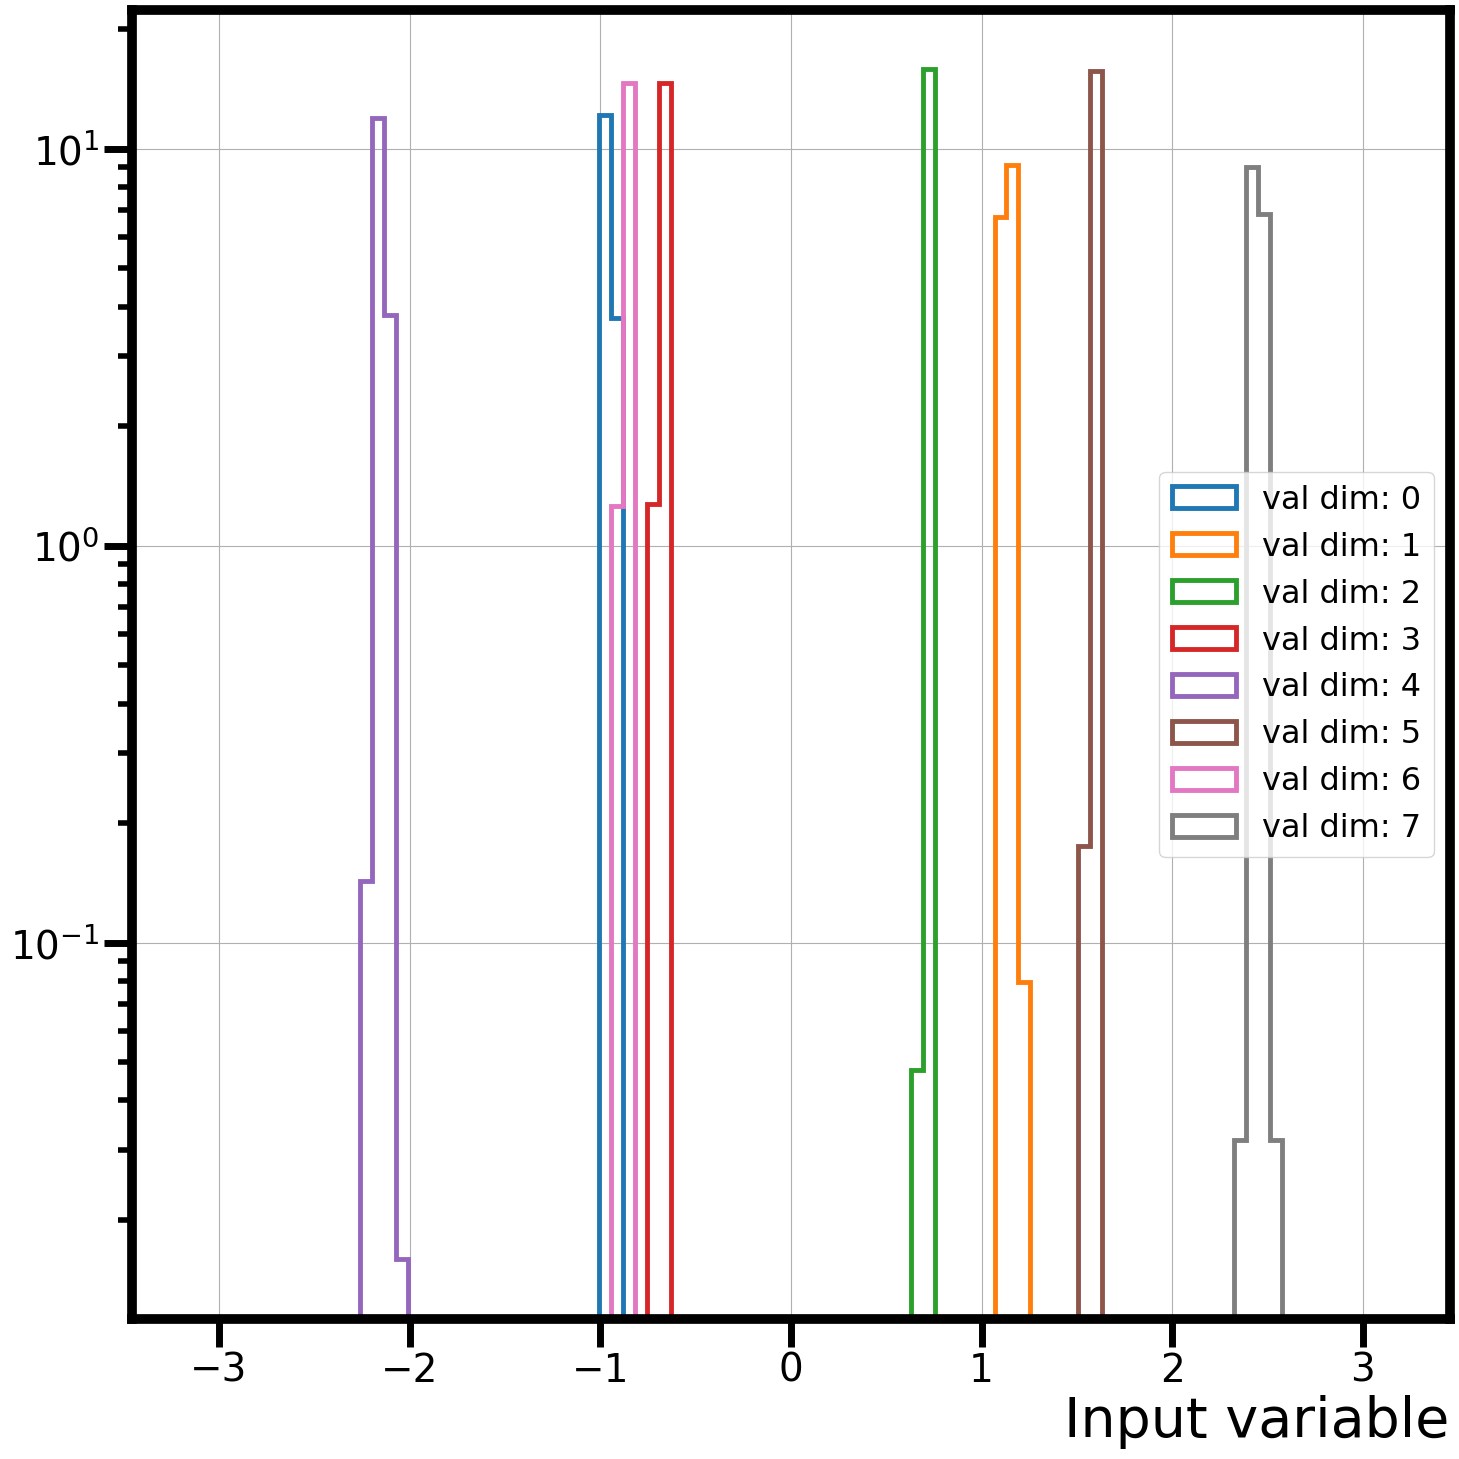

<Figure size 1700x1700 with 0 Axes>

In [12]:
QAE_model = fromYaml('model/configs/EmbeddingPennyLaneQAEModel.yaml',output_path+'/models/QAE')
input_shape = background_embeddings.shape[0]
input_length = len(background_data_frame)
input_length = len(background_data_frame)
QAE_model.build_model(input_shape,embedding_min, embedding_max )
QAE_model.compile_model(input_length)
QAE_model.only_QAE_fit(background_embeddings)
QAE_model.save()
QAE_model.plot_loss()

In [13]:
QAE_model = fromFolder(output_path+'/models/QAE')

# Train the HW substrate QAE Model

Re-created existing directory: C2V/transformer/QCD/models/HW_QAE.
circuit_weights: [ 0.00847306 -0.00526432  0.00405483  0.000751   -0.00164805 -0.00518188
  0.01294991  0.00410681 -0.00716133 -0.00236852  0.00608696 -0.01036248
  0.01693964 -0.00792157  0.01383404  0.00382681  0.00417215 -0.00430251
  0.01440712 -0.01350699  0.00650563  0.01747486 -0.00664678 -0.01216362
  0.00117431  0.00181156 -0.00706437  0.00585324  0.03070076 -0.0085705
  0.01076135 -0.00297703]
Device: lightning.gpu
Device wires: 16
Shots: Shots(total=1000)
Level: gradient

Resource specifications:
  Total wire allocations: 16
  Total gates: 57
  Circuit depth: 17

  Gate types:
    RY: 16
    RZ: 16
    RX: 8
    CNOT: 7
    CSWAP: 8
    Hadamard: 2

  Measurements:
    sample(Projector): 1
Iter:    1 | Cost: 0.4935800 | Validation Cost: 0.4896800
Iter:    2 | Cost: 0.4686200 | Validation Cost: 0.4692100
Iter:    3 | Cost: 0.4090700 | Validation Cost: 0.4109200
Iter:    4 | Cost: 0.3187900 | Validation Cost: 0.

<Figure size 640x480 with 0 Axes>

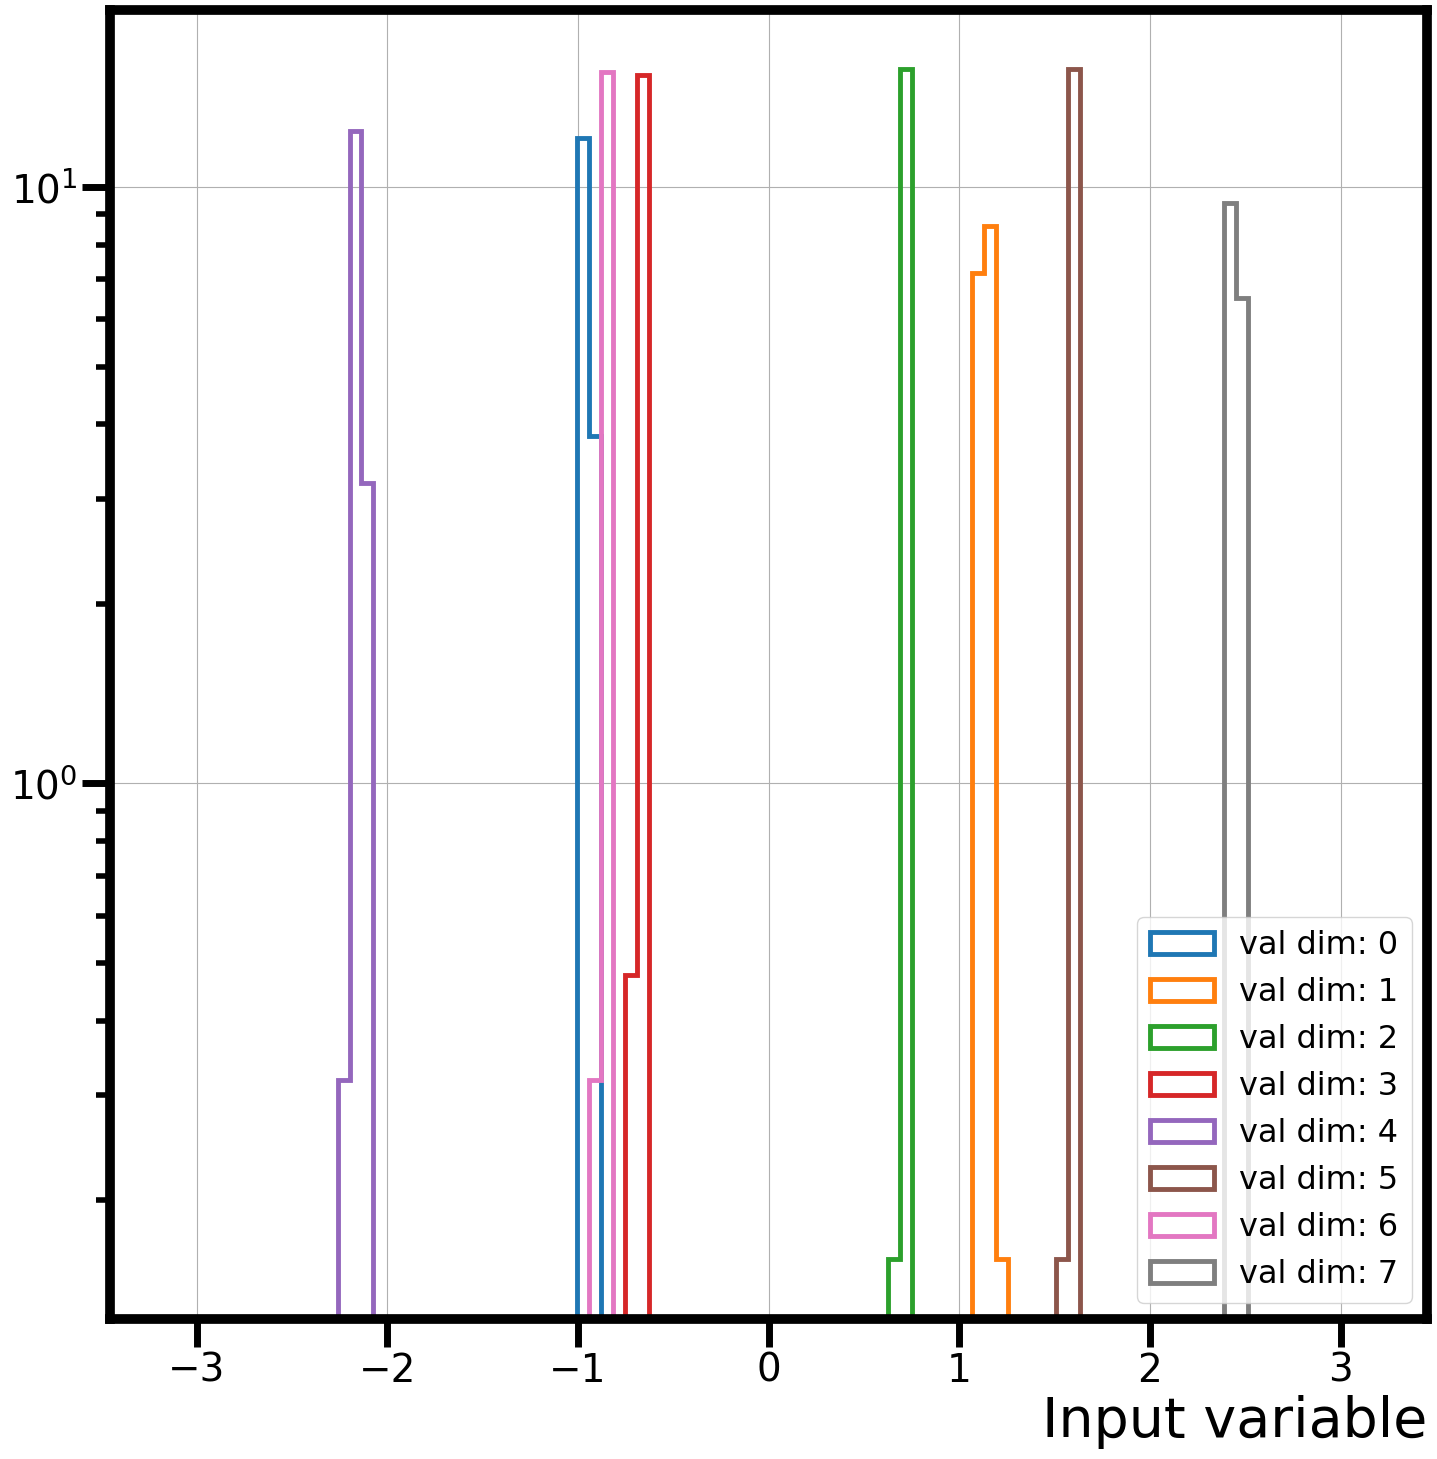

<Figure size 1700x1700 with 0 Axes>

In [14]:
HW_QAE_model = fromYaml('model/configs/EmbeddingHWPennyLaneQAEModel.yaml',output_path+'/models/HW_QAE')
input_shape = background_embeddings.shape[0]
input_length = len(background_data_frame)
input_length = len(background_data_frame)
HW_QAE_model.build_model(input_shape,embedding_min, embedding_max )
HW_QAE_model.compile_model(input_length)
HW_QAE_model.only_QAE_fit(background_embeddings)
HW_QAE_model.save()
HW_QAE_model.plot_loss()

In [15]:
HW_QAE_model = fromFolder(output_path+'/models/HW_QAE')

# Evaluate the models

In [16]:
test_labels = {"minbias" : 0, "QCD_HT50toInf" :1, "HH_4b" : 2, 'HH_bbgammagamma':3,'HH_bbtautau':4,'QCD_HT50tobb':5}

## Run the embedding prediction

In [17]:
training_columns = []
dataset_list = []
for datasets in test_labels.keys():
    data_test = DataSet.fromH5(input_path+datasets+'/test/')
    data_test.normalise()

    data_test.set_label(test_labels[datasets])
    dataset_list.append(data_test)
    training_columns = data_test.training_columns
        
test_data_frame = pd.concat([dataset.data_frame for dataset in dataset_list])
test_data_frame = test_data_frame.sample(frac=1)

test_embeddings = embedding_model.encoder_predict(test_data_frame[training_columns].to_numpy(),training_columns) 

KeyboardInterrupt: 

In [18]:
os.makedirs(output_path+'/embeddings/test', exist_ok=True)
np.save(output_path+'/embeddings/test/test_embeddings.npy',test_embeddings)
test_data_frame.to_pickle(output_path+'/embeddings/test/dataset.pkl')

NameError: name 'test_embeddings' is not defined

## Load the embeddings

In [19]:
test_embeddings = np.load(output_path+'/embeddings/test/test_embeddings.npy')
test_data_frame = pd.read_pickle(output_path+'/embeddings/test/dataset.pkl')

In [20]:
from plot.basic import error_residual, plot_histo, rates,efficiency, clusters, plot_2d

In [21]:
test_labels = {"minbias" : 0, "QCD_HT50toInf" :1, "HH_4b" : 2, 'HH_bbgammagamma':3,'HH_bbtautau':4,'QCD_HT50tobb':5}

## Run the predictions with the AE models

In [36]:

output_dict = {'CAE' : {"minbias" : {}, "QCD_HT50toInf" :{}, "HH_4b" : {}, "HH_bbgammagamma" : {}, "HH_bbtautau" : {}, "QCD_HT50tobb": {}},
               'IF'  : {"minbias" : {}, "QCD_HT50toInf" :{}, "HH_4b" : {}, "HH_bbgammagamma" : {}, "HH_bbtautau" : {}, "QCD_HT50tobb": {}},
               'QAE' : {"minbias" : {}, "QCD_HT50toInf" :{}, "HH_4b" : {}, "HH_bbgammagamma" : {}, "HH_bbtautau" : {}, "QCD_HT50tobb": {}},
               'HW_QAE' : {"minbias" : {}, "QCD_HT50toInf" :{}, "HH_4b" : {}, "HH_bbgammagamma" : {}, "HH_bbtautau" : {}, "QCD_HT50tobb": {}}}

for label in test_labels.keys():
    print("==== Predicting for "+label+" ====")
    indices = np.where(test_data_frame["event_label"] == test_labels[label])
    test_index = np.random.randint(0, len(indices[0]), size=100000)
    embeddings = test_embeddings[indices[0][test_index]]
    data_frame = test_data_frame.iloc[indices[0][test_index]]

    print("Classical Autoencoder Predict")
    output_dict['CAE'][label] = {'predictions' : CAE_model.only_CAE_predict(embeddings)}
    print("Isolation Forest Predict")
    output_dict['IF'][label]  = {'predictions' : IF_model.predict_on_embedding(embeddings)}
    print("Quantum Autoencoder Predict")
    output_dict['QAE'][label] = {'predictions' : QAE_model.only_QAE_predict(embeddings)}
    print("HW Quantum Autoencoder Predict")
    output_dict['HW_QAE'][label] = {'predictions' : HW_QAE_model.only_QAE_predict(embeddings)}    
    


==== Predicting for minbias ====
Classical Autoencoder Predict
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
Isolation Forest Predict
Quantum Autoencoder Predict
HW Quantum Autoencoder Predict
==== Predicting for QCD_HT50toInf ====
Classical Autoencoder Predict
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
Isolation Forest Predict
Quantum Autoencoder Predict
HW Quantum Autoencoder Predict
==== Predicting for HH_4b ====
Classical Autoencoder Predict
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
Isolation Forest Predict
Quantum Autoencoder Predict
HW Quantum Autoencoder Predict
==== Predicting for HH_bbgammagamma ====
Classical Autoencoder Predict
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
Isolation Forest Predict
Quantum Autoencoder Predict
HW Quantum Autoencoder Predict
==== Predicting for HH_bbtautau ====
Classical Autoencoder Predict
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
Isolation Forest Predict
Quantum Autoencoder Predict
HW Quantum Autoencoder Predict
==== Predicting for QCD_HT50tobb 

In [37]:
with open(output_path+'/models/output_dict.pkl', 'wb') as f:
    pickle.dump(output_dict, f)

## Load the predictions

In [38]:
with open(output_path+'/models/output_dict.pkl', 'rb') as f:
    output_dict = pickle.load(f)

# Plot per model output predictions labeled per event type

In [39]:
import matplotlib.pyplot as plt

plot_histo([output_dict['CAE'][dataset]['predictions'] for dataset in output_dict['CAE'].keys()], 
               [dataset for dataset in output_dict['CAE'].keys()], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)
os.makedirs(output_path+"/models/CAE/plots/testing/", exist_ok=True)
plt.savefig(f"{output_path}/models/CAE/plots/testing/outputscores.png", bbox_inches='tight')
plt.close() 

plot_histo([output_dict['IF'][dataset]['predictions'] for dataset in output_dict['IF'].keys()], 
               [dataset for dataset in output_dict['IF'].keys()], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)
os.makedirs(output_path+"/models/IF/plots/testing/", exist_ok=True)
plt.savefig(f"{output_path}/models/IF/plots/testing/outputscores.png", bbox_inches='tight')
plt.close() 

plot_histo([output_dict['QAE'][dataset]['predictions'] for dataset in output_dict['QAE'].keys()], 
               [dataset for dataset in output_dict['QAE'].keys()], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)
os.makedirs(output_path+"/models/QAE/plots/testing/", exist_ok=True)
plt.savefig(f"{output_path}/models/QAE/plots/testing/outputscores.png", bbox_inches='tight')
plt.close() 

plot_histo([output_dict['HW_QAE'][dataset]['predictions'] for dataset in output_dict['QAE'].keys()], 
               [dataset for dataset in output_dict['HW_QAE'].keys()], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)
os.makedirs(output_path+"/models/HW_QAE/plots/testing/", exist_ok=True)
plt.savefig(f"{output_path}/models/HW_QAE/plots/testing/outputscores.png", bbox_inches='tight')
plt.close() 

<Figure size 640x480 with 0 Axes>

# Plot per process output scores labelled per model

In [40]:
os.makedirs(output_path+"/plots/testing/", exist_ok=True)
for label in test_labels.keys():
    plot_histo([output_dict['CAE'][label]['predictions'],output_dict['IF'][label]['predictions'],output_dict['QAE'][label]['predictions'],output_dict['HW_QAE'][label]['predictions']], 
               ['CAE','IF','QAE','HW_QAE'], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)
    plt.savefig(f"{output_path}/plots/testing/{label}_outputscores.png", bbox_inches='tight')
    plt.close() 

<Figure size 640x480 with 0 Axes>

# Plot per model ROC curves labelled per process

In [41]:
from plot.basic import ROC_curve

ROC_curve([output_dict['CAE']['minbias']['predictions'] for dataset in output_dict['CAE'].keys()],
          [output_dict['CAE'][dataset]['predictions'] for dataset in output_dict['CAE'].keys()],
          test_labels)
plt.savefig(f"{output_path}/models/CAE/plots/testing/ROC.png", bbox_inches='tight')
plt.close() 

ROC_curve([output_dict['IF']['minbias']['predictions'] for dataset in output_dict['IF'].keys()],
          [output_dict['IF'][dataset]['predictions'] for dataset in output_dict['IF'].keys()],
          test_labels)
plt.savefig(f"{output_path}/models/IF/plots/testing/ROC.png", bbox_inches='tight')
plt.close() 

ROC_curve([output_dict['QAE']['minbias']['predictions'] for dataset in output_dict['QAE'].keys()],
          [output_dict['QAE'][dataset]['predictions'] for dataset in output_dict['QAE'].keys()],
          test_labels)
plt.savefig(f"{output_path}/models/QAE/plots/testing/ROC.png", bbox_inches='tight')
plt.close() 

ROC_curve([output_dict['HW_QAE']['minbias']['predictions'] for dataset in output_dict['HW_QAE'].keys()],
          [output_dict['HW_QAE'][dataset]['predictions'] for dataset in output_dict['HW_QAE'].keys()],
          test_labels)
plt.savefig(f"{output_path}/models/HW_QAE/plots/testing/ROC.png", bbox_inches='tight')
plt.close() 



# Plot per process ROC curves labelled per model

In [42]:
for label in test_labels.keys():
    ROC_curve([output_dict['CAE']['minbias']['predictions'],output_dict['IF']['minbias']['predictions'],output_dict['QAE']['minbias']['predictions'],output_dict['HW_QAE']['minbias']['predictions']],
              [output_dict['CAE'][label]['predictions'],output_dict['IF'][label]['predictions'],output_dict['QAE'][label]['predictions'],output_dict['HW_QAE'][label]['predictions']],
              ['CAE','IF','QAE','HW_QAE'])
    
    plt.savefig(f"{output_path}/plots/testing/{label}_ROC.png", bbox_inches='tight')
    plt.close() 


# Augmentations

In [29]:
from plot.plot_latent import plot_latent, plot_PCA
from sklearn.decomposition import PCA

In [31]:
training_columns = []
dataset_list = []

for datasets in test_labels.keys():
    print(datasets)
    data_test = DataSet.fromH5(input_path+datasets+'/test/')
    data_test_dataframe = data_test.data_frame.sample(n=10000)
    
    #augment_test.drop_a_soft_one('jet')
    data_test.eta_smear()
    data_test.pt_smear()
    data_test.phi_smear()
    #data_test.phi_rotate()
    
    data_test.normalise()

    data_test.set_label(test_labels[datasets])
    dataset_list.append(data_test)
    training_columns = data_test.training_columns
        
augment_data_frame = pd.concat([dataset.data_frame for dataset in dataset_list])
augment_data_frame = augment_data_frame.sample(frac=1)

augment_embeddings = embedding_model.encoder_predict(augment_data_frame[training_columns].to_numpy(),training_columns) 

minbias
               index  L1T_JetPuppiAK4_PT0  L1T_JetPuppiAK4_Eta0  \
count  870326.000000        870326.000000         870326.000000   
mean   435162.500000            20.305567              0.000884   
std    251241.619529            17.652438              2.327915   
min         0.000000             0.000000             -4.500000   
25%    217581.250000             0.000000             -1.576941   
50%    435162.500000            22.243101              0.000000   
75%    652743.750000            28.883277              1.575198   
max    870325.000000           529.498120              4.500000   

       L1T_JetPuppiAK4_Phi0  L1T_JetPuppiAK4_PT1  L1T_JetPuppiAK4_Eta1  \
count         870326.000000        870326.000000         870326.000000   
mean              -0.003237             1.376485             -0.001939   
std                1.491978             6.378583              0.608556   
min               -3.141561             0.000000             -4.500000   
25%               

2026-04-16 12:44:17.105942: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 12:44:17.105991: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 12:44:17.106102: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


711/719 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

2026-04-16 12:44:24.691456: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 12:44:24.691508: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 12:44:24.691656: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


719/719 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step


In [32]:
os.makedirs(output_path+'/embeddings/augment', exist_ok=True)
np.save(output_path+'/embeddings/augment/augment_embeddings.npy',augment_embeddings)
augment_data_frame.to_pickle(output_path+'/embeddings/augment/dataset.pkl')

In [33]:
augment_embeddings = np.load(output_path+'/embeddings/augment/augment_embeddings.npy')
augment_data_frame = pd.read_pickle(output_path+'/embeddings/augment/dataset.pkl')

# Compare Latent Spaces for background Sample

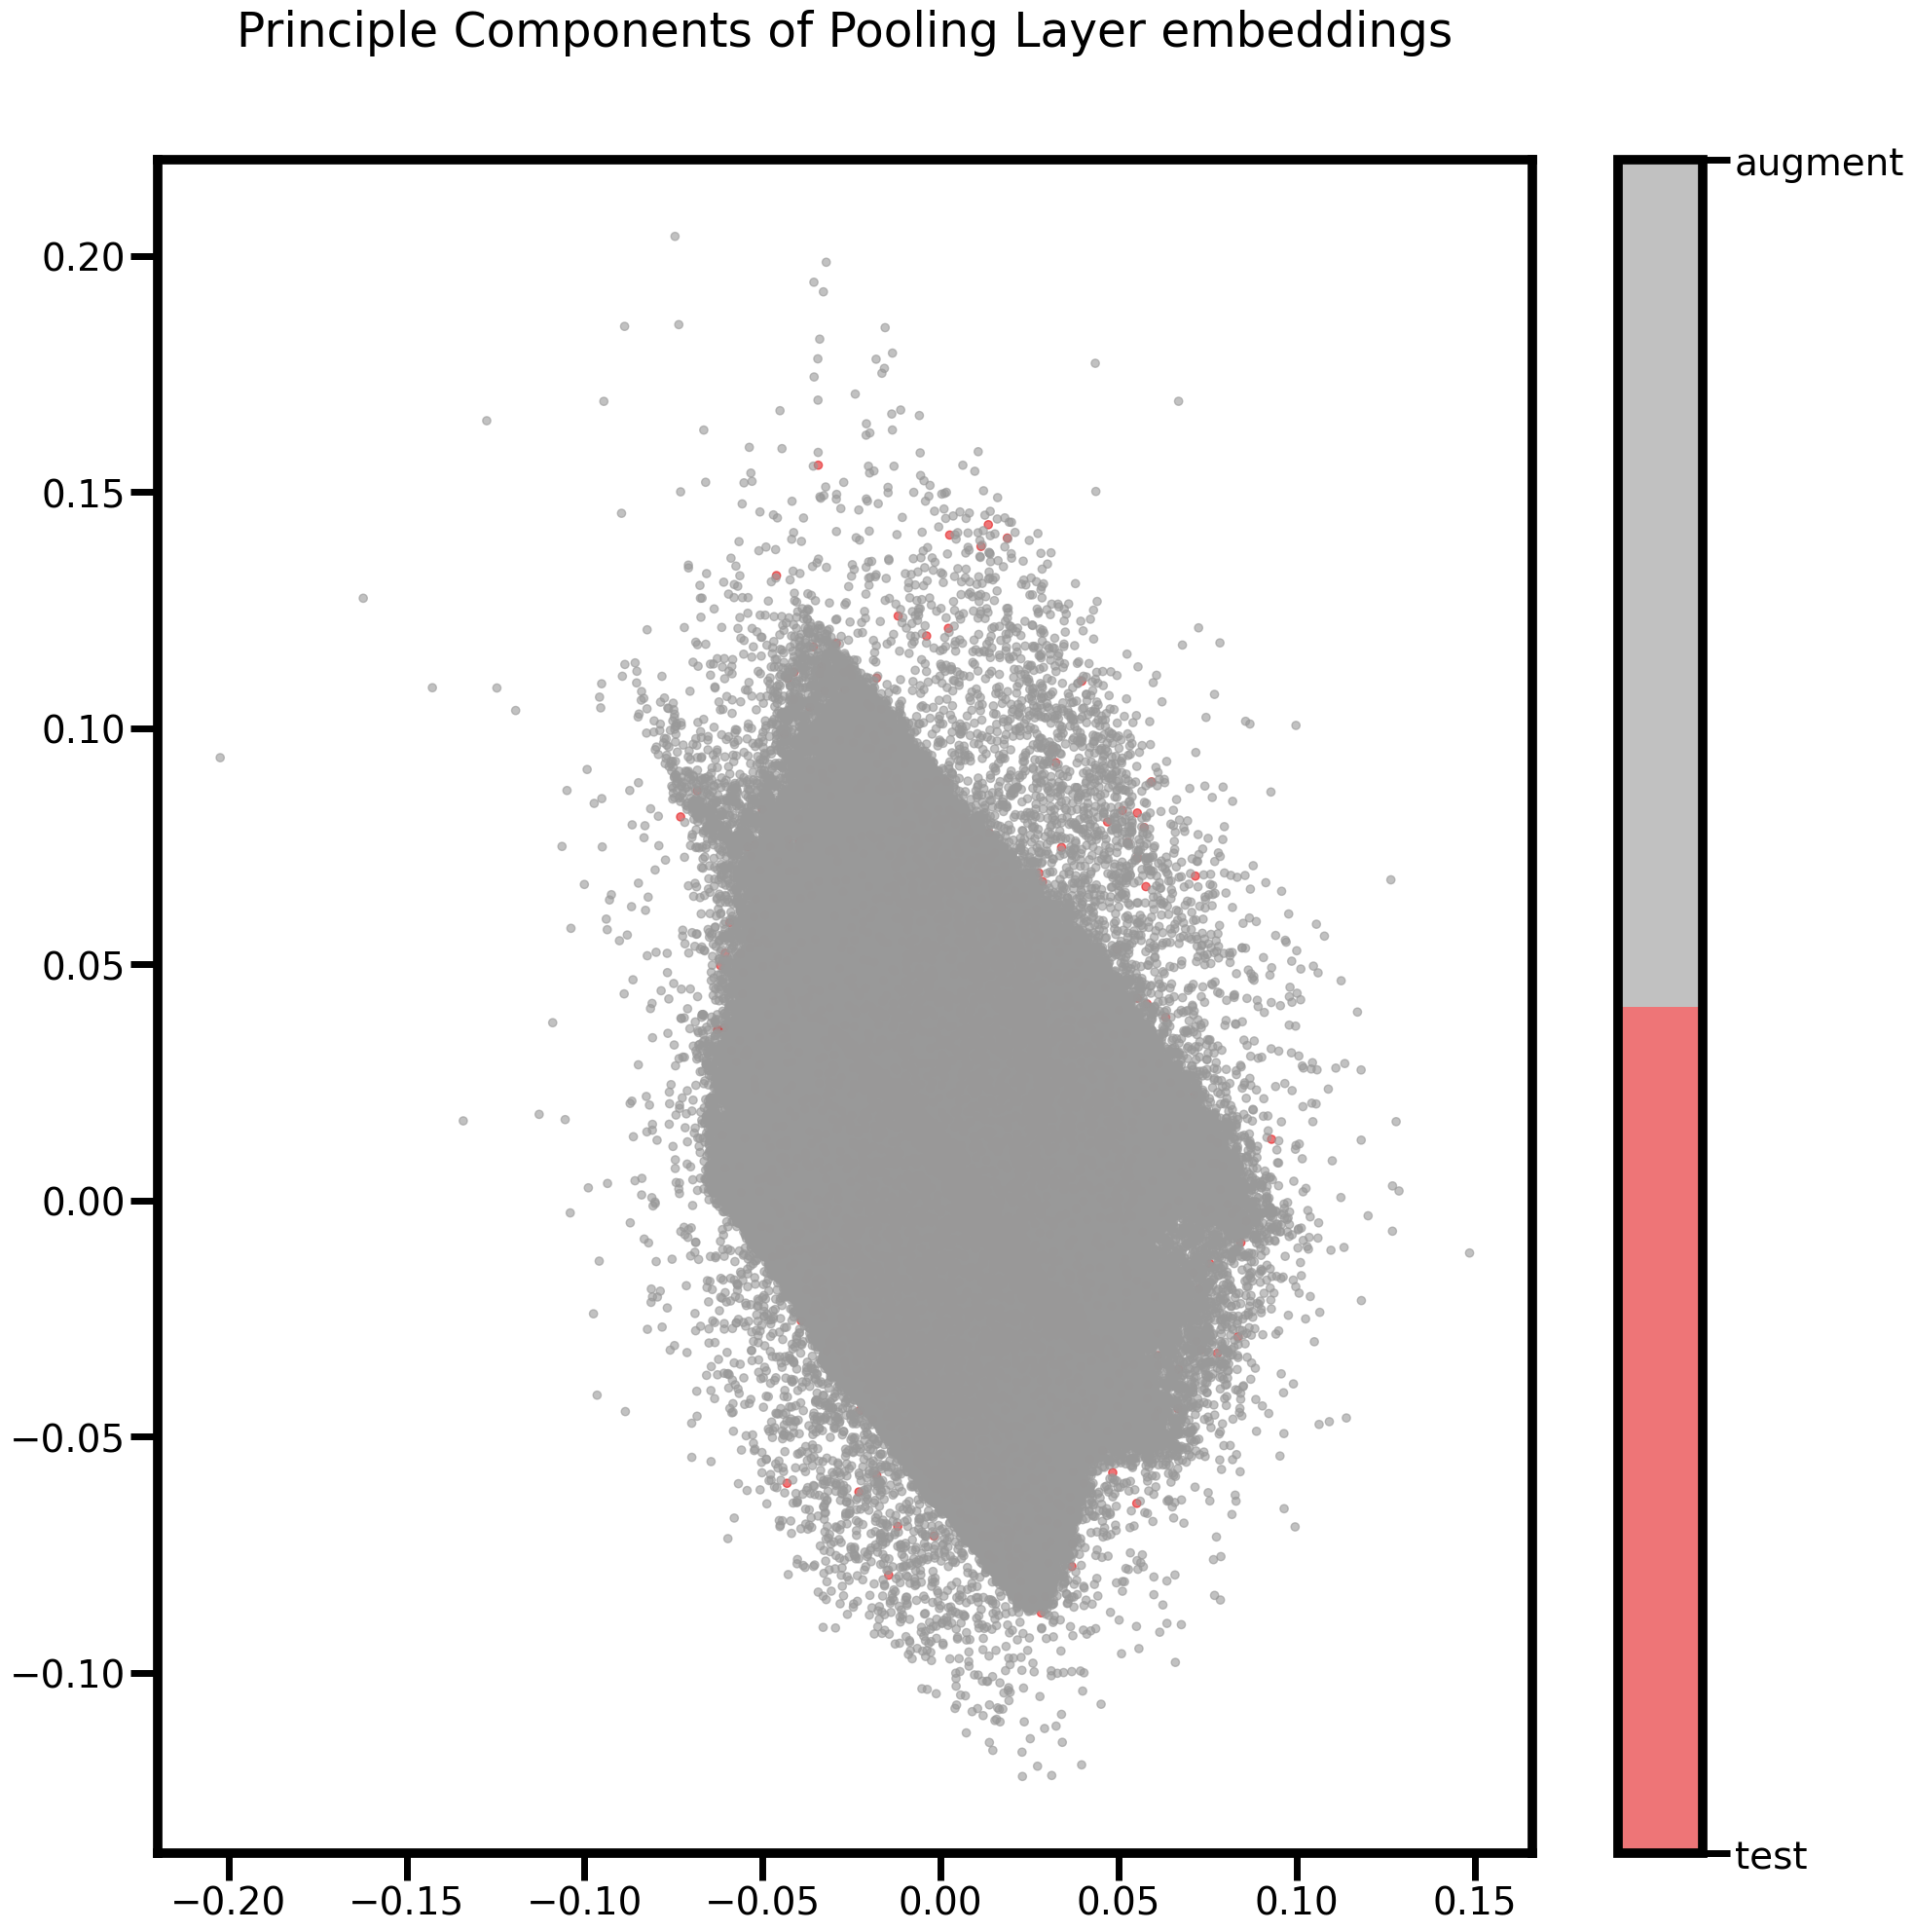

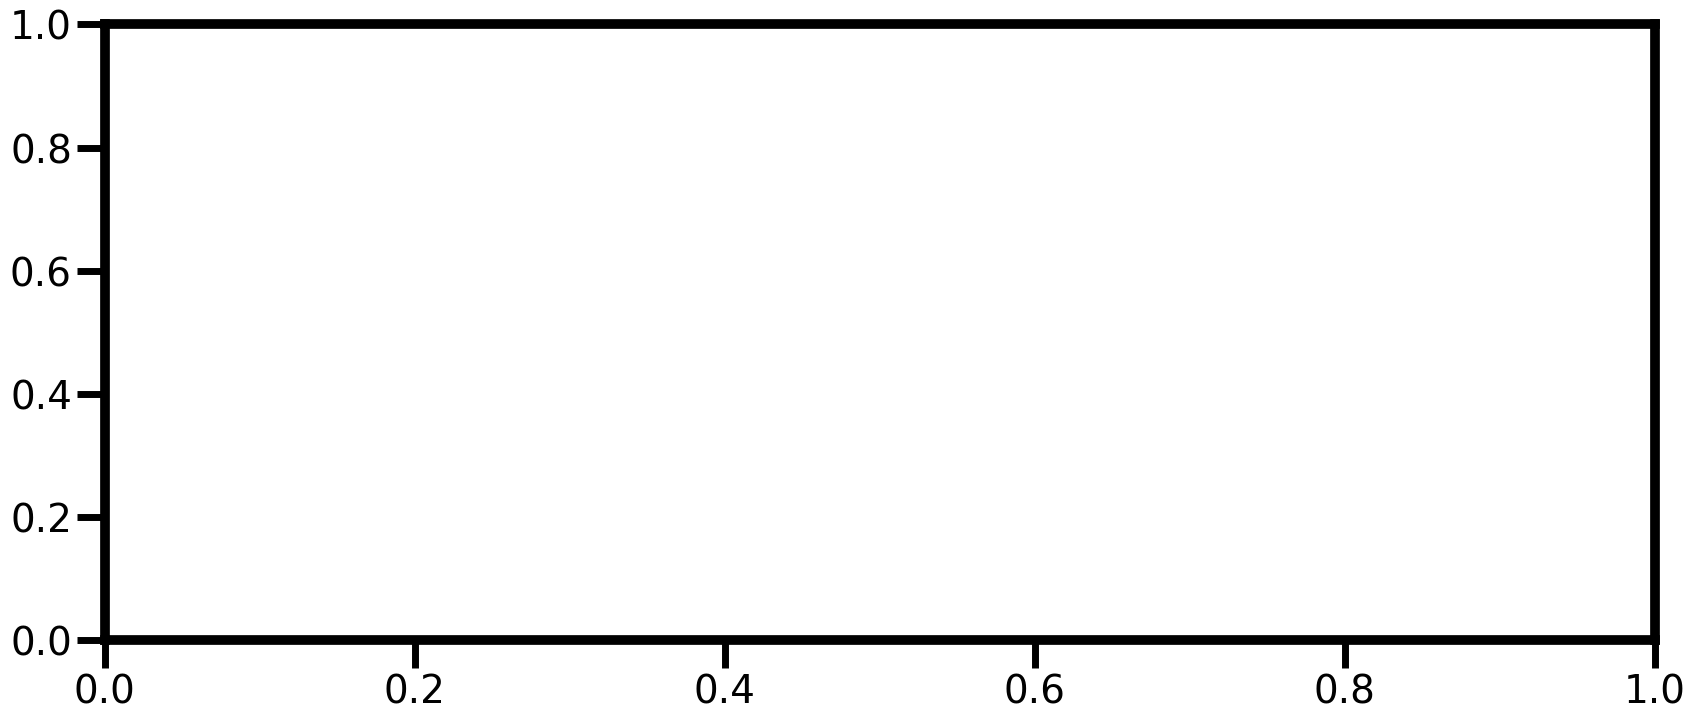

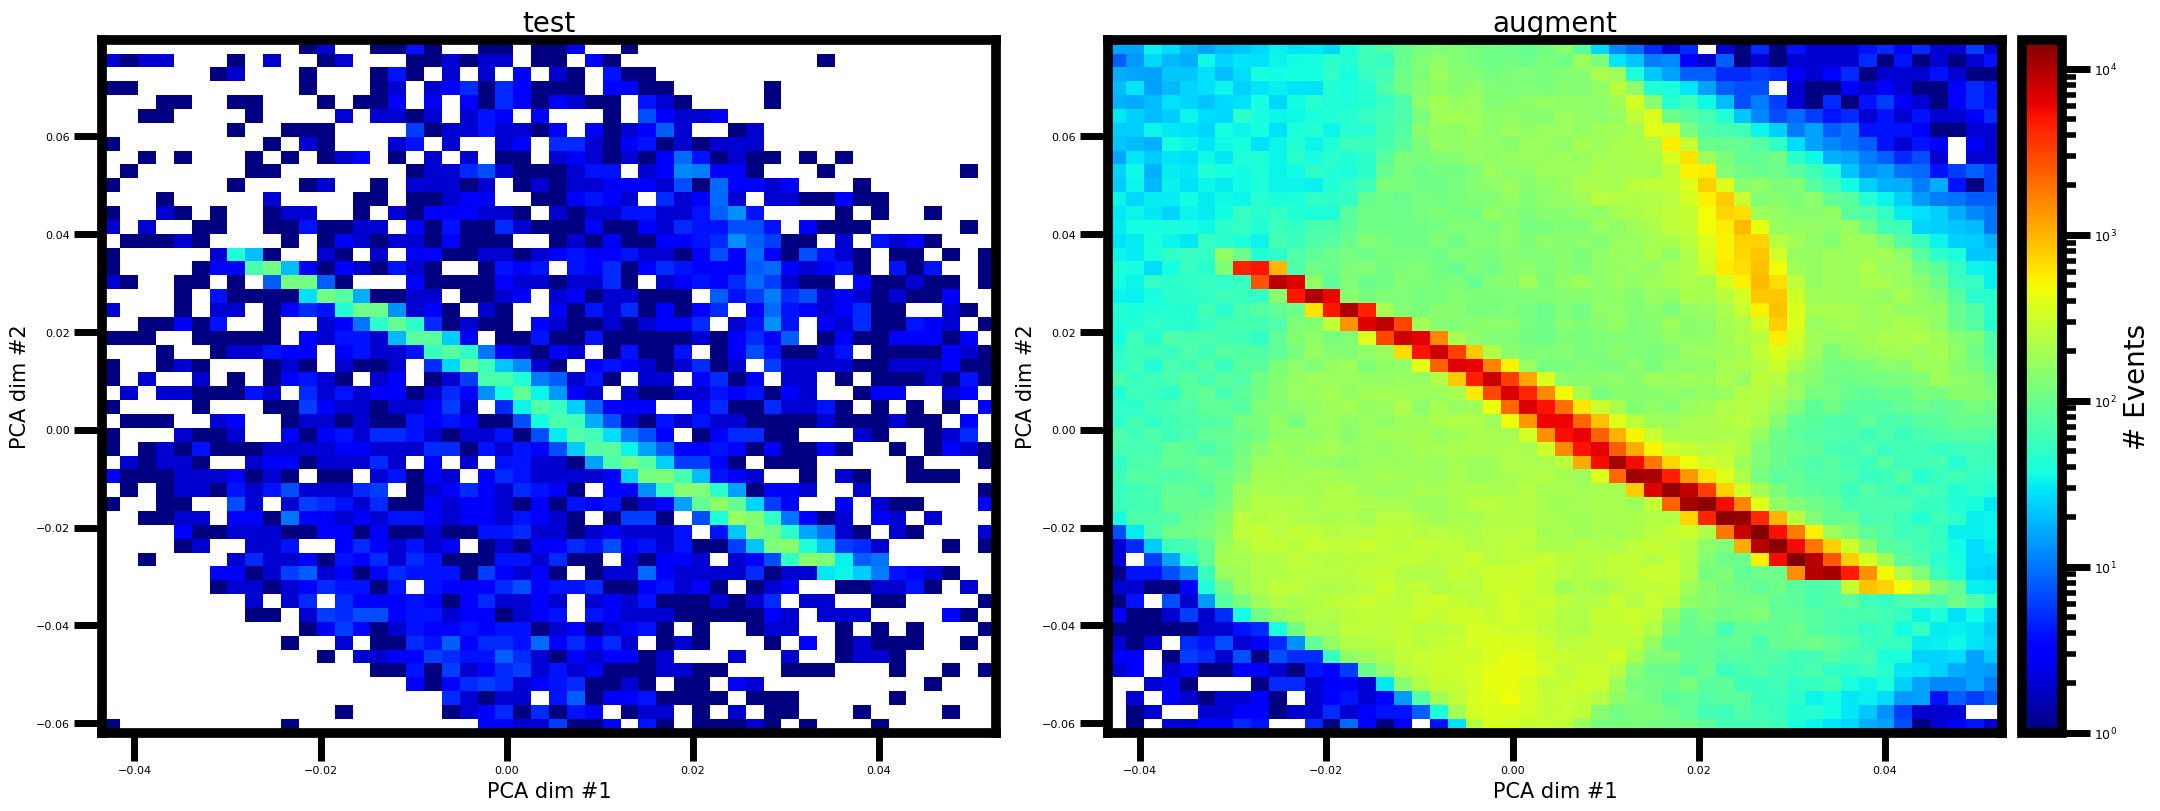

In [35]:
background_indices = np.where(test_data_frame["event_label"] == 0)
test_index = np.random.randint(0, len(background_indices[0]), size=10000)
background_test_embeddings = test_embeddings[background_indices[0][test_index]]
background_test_data_frame = test_data_frame.iloc[background_indices[0][test_index]]

background_indices = np.where(augment_data_frame["event_label"] == 0)
background_augment_embeddings = augment_embeddings[background_indices]
background_augment_data_frame = augment_data_frame.iloc[background_indices]
    
latent_vector = np.concatenate([background_test_embeddings,background_augment_embeddings], axis=0)
event_label_vector = np.concatenate([np.zeros(len(background_test_embeddings)),np.ones(len(background_augment_embeddings))], axis=0)

os.makedirs(f"{output_path}/embeddings/plots/background", exist_ok=True)

plot_latent(latent_vector, event_label_vector, {'test':'test','augment':'augment'}, f"{output_path}/embeddings/plots/background")
    
pca = PCA(n_components=2)
event_principle_components = pca.fit_transform(latent_vector)

event_xmax, event_xmin = np.percentile(event_principle_components[:,0],99), np.percentile(event_principle_components[:,0],1)
event_ymax, event_ymin = np.percentile(event_principle_components[:,1],99), np.percentile(event_principle_components[:,1],1)
    
plot_PCA(event_principle_components, event_label_vector,((event_xmin, event_xmax),(event_ymin, event_ymax)), {'test':'test','augment':'augment'}, f"{output_path}/embeddings/plots/background")




